# Part 2: Automated Policy Design

## Overview
This notebook implements a automated policy design for the World3 model. The workflow is:
1. Run baseline and explore all output variables
2. Use correlation and discrimination analysis to select sustainability indicators
3. Use single-parameter scans to determine grid search ranges
4. Define the sustainability score based on exploration results
5. Run automated grid search over 500 policy scenarios
6. Analyse and visualise results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time
from itertools import product
warnings.filterwarnings('ignore')
import pyworld3
print('pyworld3 loaded.')

pyworld3 loaded.


In [2]:
def run_world3(pyear=1975, year_max=2100, **constants):
    w3 = pyworld3.World3(year_max=year_max, pyear=pyear)
    w3.init_world3_constants(**constants)
    w3.init_world3_variables()
    w3.set_world3_table_functions()
    w3.set_world3_delay_functions()
    w3.run_world3()
    return w3

def get_time(model):
    return np.arange(model.year_min, model.year_max + model.dt, model.dt)

baseline = run_world3()
t = get_time(baseline)
print(f'Baseline OK. {t[0]:.0f}–{t[-1]:.0f}, {len(t)} steps.')

Baseline OK. 1900–2100, 401 steps.


## Step 1: Explore Variable Behavior in Baseline

We first examine how all output variables behave in the baseline run (2000–2100),
specifically looking at peak-to-2100 collapse magnitude to identify which variables
experience meaningful decline and are therefore candidates for sustainability indicators.

In [3]:
# Analyze key variables for collapse risk
candidate_vars = ['pop', 'nr', 'le', 'ppolx', 'fpc', 'iopc',
                  'io', 'cdr', 'cbr', 'lmf', 'lmhs', 'lmp', 'fce', 'fcaor']

print(f"{'Var':<8} {'2000':>10} {'2050':>10} {'2100':>10} {'PeakDrop%':>10} {'Note'}")
print("-" * 65)

var_stats = {}
for var in candidate_vars:
    arr = getattr(baseline, var)
    v2000 = arr[t >= 2000][0]
    v2050 = arr[t >= 2050][0]
    v2100 = arr[-1]
    peak  = arr.max()
    drop  = (peak - v2100) / (abs(peak) + 1e-9) * 100
    change_pct = (v2100 - v2000) / (abs(v2000) + 1e-9) * 100
    var_stats[var] = {'drop': drop, 'change': change_pct,
                      'v2000': v2000, 'v2050': v2050, 'v2100': v2100}
    note = '<-- large collapse' if drop > 30 else ''
    print(f"{var:<8} {v2000:>10.3f} {v2050:>10.3f} {v2100:>10.3f} {drop:>+9.1f}%  {note}")

Var            2000       2050       2100  PeakDrop% Note
-----------------------------------------------------------------
pop      5643475565.014 6237602834.836 3976857676.148     +43.7%  <-- large collapse
nr       688022094219.748 196045439270.995 152023587005.392     +84.8%  <-- large collapse
le           54.735     38.994     27.763     +54.8%  <-- large collapse
ppolx         3.530      7.592      0.602     +94.5%  <-- large collapse
fpc         495.124    256.573    235.747     +53.4%  <-- large collapse
iopc        351.750     89.381     10.711     +97.3%  <-- large collapse
io       1985092990946.341 557522784556.874 42594878499.226     +98.4%  <-- large collapse
cdr          14.743     28.785     38.136      +0.0%  
cbr          27.236     19.089     30.689      +nan%  
lmf           1.215      1.023      1.005     +17.6%  
lmhs          1.566      1.618      1.218     +32.1%  <-- large collapse
lmp           0.996      0.992      0.999      +0.1%  
fce           0.955     

## Step 2: Correlation Analysis

To avoid double-counting, we compute pairwise correlations between all candidate
variables over 2000–2100. Variables with |r| > 0.85 against an already-selected
indicator are excluded, since they carry redundant information.

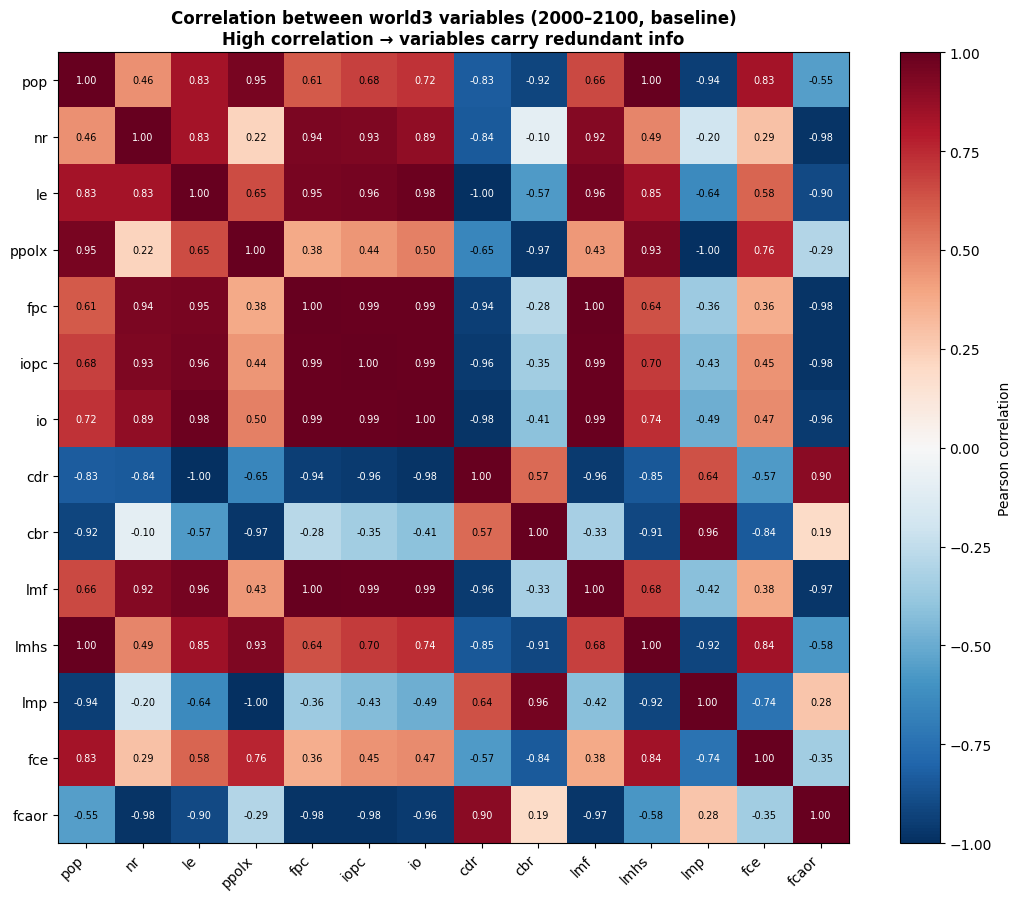


Highly correlated pairs (|r| > 0.85) — avoid using both:
  pop & ppolx: r = 0.95
  pop & cbr: r = -0.92
  pop & lmhs: r = 1.00
  pop & lmp: r = -0.94
  nr & fpc: r = 0.94
  nr & iopc: r = 0.93
  nr & io: r = 0.89
  nr & lmf: r = 0.92
  nr & fcaor: r = -0.98
  le & fpc: r = 0.95
  le & iopc: r = 0.96
  le & io: r = 0.98
  le & cdr: r = -1.00
  le & lmf: r = 0.96
  le & fcaor: r = -0.90
  ppolx & cbr: r = -0.97
  ppolx & lmhs: r = 0.93
  ppolx & lmp: r = -1.00
  fpc & iopc: r = 0.99
  fpc & io: r = 0.99
  fpc & cdr: r = -0.94
  fpc & lmf: r = 1.00
  fpc & fcaor: r = -0.98
  iopc & io: r = 0.99
  iopc & cdr: r = -0.96
  iopc & lmf: r = 0.99
  iopc & fcaor: r = -0.98
  io & cdr: r = -0.98
  io & lmf: r = 0.99
  io & fcaor: r = -0.96
  cdr & lmf: r = -0.96
  cdr & fcaor: r = 0.90
  cbr & lmhs: r = -0.91
  cbr & lmp: r = 0.96
  lmf & fcaor: r = -0.97
  lmhs & lmp: r = -0.92


In [4]:
mask    = t >= 2000
data    = {v: getattr(baseline, v)[mask]
           for v in candidate_vars
           if getattr(baseline, v).shape == t.shape}
df_corr = pd.DataFrame(data).corr().round(2)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(df_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(df_corr.columns)))
ax.set_yticks(range(len(df_corr.columns)))
ax.set_xticklabels(df_corr.columns, rotation=45, ha='right')
ax.set_yticklabels(df_corr.columns)
for i in range(len(df_corr)):
    for j in range(len(df_corr.columns)):
        ax.text(j, i, f'{df_corr.values[i,j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='white' if abs(df_corr.values[i,j]) > 0.7 else 'black')
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation between world3 variables (2000–2100, baseline)\n'
             'High correlation → variables carry redundant info', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.85) — avoid using both:")
for i, v1 in enumerate(df_corr.columns):
    for j, v2 in enumerate(df_corr.columns):
        if i < j and abs(df_corr.loc[v1, v2]) > 0.85:
            print(f"  {v1} & {v2}: r = {df_corr.loc[v1,v2]:.2f}")

## Step 3: Discrimination Power Test

A good sustainability indicator must distinguish between good and bad policies.
We run six contrasting scenarios and measure how much each variable differs
across them. Variables with a large range are more informative indicators.

The six scenarios are:
- **baseline**: no policy change
- **nr_strong**: 75% reduction in resource usage (`nruf2=0.25`)
- **pol_strong**: 75% reduction in pollution generation (`ppgf2=0.25`)
- **pop_strong**: strong birth control (`dcfsn=2.0`)
- **all_strong**: all three policies combined
- **worse**: increased resource and pollution pressure

In [ ]:
scenarios = {
    'baseline':   run_world3(),
    'nr_strong':  run_world3(nruf2=0.25),
    'pol_strong': run_world3(ppgf2=0.25),
    'pop_strong': run_world3(dcfsn=2.0),
    'all_strong': run_world3(nruf2=0.25, ppgf2=0.25, dcfsn=2.0),
    'worse':      run_world3(nruf2=1.5, ppgf2=1.5),
}

final_vars = ['pop', 'nr', 'le', 'ppolx', 'fpc', 'iopc', 'cdr', 'lmf']
base_means = {v: getattr(baseline, v)[t >= 2050].mean() for v in final_vars}

rows = []
for name, model in scenarios.items():
    t_ = get_time(model)
    row = {'scenario': name}
    for v in final_vars:
        arr  = getattr(model, v)
        mean = arr[t_ >= 2050].mean()
        row[v] = mean / (base_means[v] + 1e-9)  # ratio to baseline
    rows.append(row)

df_disc = pd.DataFrame(rows).set_index('scenario')
print("Variable values relative to baseline (2050–2100 avg):")
print("Values far from 1.0 = high discrimination power")
print(df_disc.round(2).to_string())

# Discrimination score = range across scenarios (higher = better indicator)
disc = df_disc.max() - df_disc.min()
disc_sorted = disc.sort_values(ascending=False)
print(f"\nDiscrimination power (range across scenarios):")
for v, d in disc_sorted.items():
    bar = '█' * int(d * 10)
    print(f"  {v:<8}: {d:.3f}  {bar}")

Variable values relative to baseline (2050–2100 avg):
Values far from 1.0 = high discrimination power
             pop    nr    le  ppolx   fpc   iopc   cdr   lmf
scenario                                                    
baseline    1.00  1.00  1.00   1.00  1.00   1.00  1.00  1.00
nr_strong   1.13  2.43  0.84  24.89  0.85  11.14  1.21  0.82
pol_strong  1.04  0.94  1.02   0.19  1.08   0.94  0.99  1.03
pop_strong  0.14  0.70  2.06   0.45  5.18   0.35  0.65  1.39
all_strong  0.16  3.41  2.41   0.29  8.04  53.83  0.50  1.41
worse       0.76  0.90  0.91   0.70  1.00   0.49  1.05  0.98

Discrimination power (range across scenarios):
  iopc    : 53.484  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

## Step 4: Single-Parameter Sensitivity Scan

Before defining the grid search, we scan each parameter individually to identify:
- The value that maximises sustainability
- The effective range where the parameter has meaningful impact

This ensures our grid search covers the right region rather than arbitrary values.

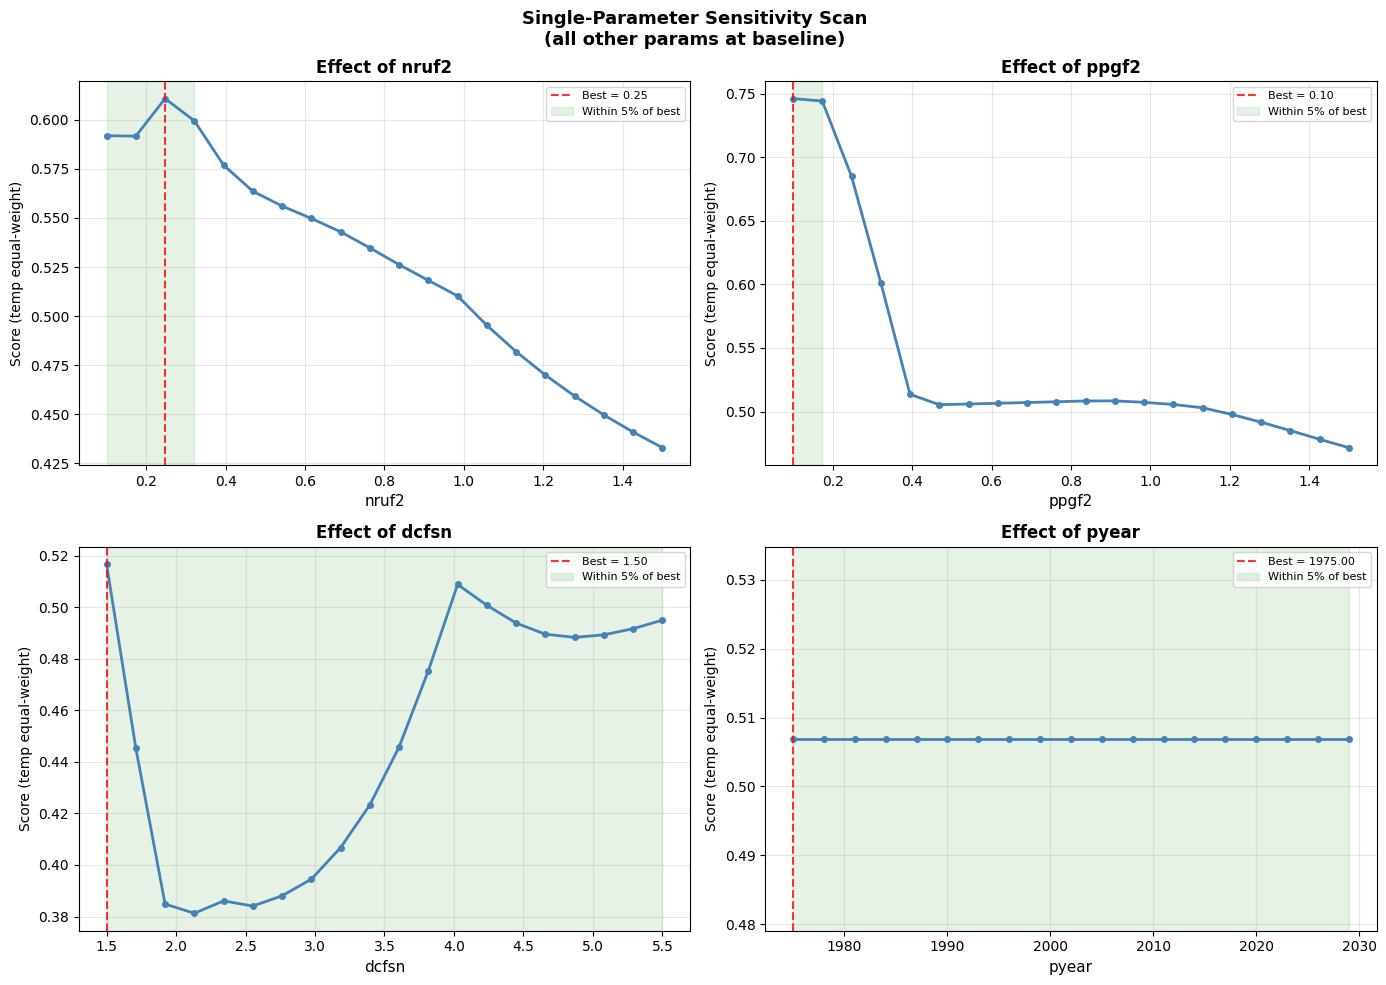


Scan summary — use this to choose grid search ranges:
  nruf2: best=0.25, effective range=[0.10, 0.32]
  ppgf2: best=0.10, effective range=[0.10, 0.17]
  dcfsn: best=1.50, effective range=[1.50, 5.50]
  pyear: best=1975.00, effective range=[1975.00, 2029.00]


In [ ]:
def temp_score(model):
    t_ = get_time(model)
    pop_late = model.pop[t_ >= 2050].mean() / 1e9
    nr_frac  = model.nr[-1] / model.nr[0]
    le_late  = model.le[t_ >= 2050].mean()
    pol_max  = model.ppolx.max()
    return (np.clip(pop_late/5,0,1) + np.clip(nr_frac/0.3,0,1) +
            np.clip(le_late/60,0,1) + np.clip(1-(pol_max-1.5)/2,0,1)) / 4

param_ranges = {
    'nruf2': np.linspace(0.1, 1.5, 20),
    'ppgf2': np.linspace(0.1, 1.5, 20),
    'dcfsn': np.linspace(1.5, 5.5, 20),
    'pyear': np.arange(1975, 2031, 3).astype(float),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Single-Parameter Sensitivity Scan\n'
             '(all other params at baseline)', fontsize=13, fontweight='bold')

scan_results = {}
for ax, (param, values) in zip(axes.flat, param_ranges.items()):
    scores = []
    for v in values:
        try:
            if param == 'pyear':
                m = run_world3(pyear=int(v))
            else:
                m = run_world3(**{param: v})
            scores.append(temp_score(m))
        except:
            scores.append(float('nan'))

    scores = np.array(scores)
    scan_results[param] = {'values': values, 'scores': scores}

    ax.plot(values, scores, 'o-', color='steelblue', lw=2, ms=4)
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Score (temp equal-weight)')
    ax.set_title(f'Effect of {param}', fontweight='bold')
    ax.grid(alpha=0.3)

    # Mark best value
    best_idx = np.nanargmax(scores)
    ax.axvline(values[best_idx], color='red', ls='--', alpha=0.8,
               label=f'Best = {values[best_idx]:.2f}')
    # Mark where effect saturates (score within 5% of best)
    threshold = np.nanmax(scores) * 0.95
    sat_idxs  = np.where(scores >= threshold)[0]
    if len(sat_idxs) > 0:
        ax.axvspan(values[sat_idxs[0]], values[sat_idxs[-1]],
                   alpha=0.1, color='green', label='Within 5% of best')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('param_scan.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary to guide grid search design
print("\nScan summary — use this to choose grid search ranges:")
for param, res in scan_results.items():
    vals   = res['values']
    scores = res['scores']
    best_v = vals[np.nanargmax(scores)]
    # Range where score > 95% of best
    thresh = np.nanmax(scores) * 0.95
    good   = vals[scores >= thresh]
    print(f"  {param}: best={best_v:.2f}, "
          f"effective range=[{good.min():.2f}, {good.max():.2f}]")

## Step 5: Define Sustainability Score

Based on the exploration above, we select four independent indicators:

| Indicator | Weight | Justification |
|---|---|---|
| Natural resources (`nr`) | 35% | High independent discrimination (2.72); irreversible depletion |
| Pollution (`ppolx`) | 30% | Highest raw discrimination (24.7); baseline peaks at 7.6 |
| Life expectancy (`le`) | 25% | Large collapse (54.8%); acts as proxy for `fpc`, `iopc`, `io` (all r > 0.95 with `le`) |
| Population (`pop`) | 10% | Lowest discrimination (0.99); used as crash detector only |

**Excluded variables:**
- `fpc`, `iopc`, `io`: all r > 0.95 with `le` → redundant
- `cdr`: r = −1.00 with `le` → perfectly redundant
- `lmhs`: r = 1.00 with `pop` → perfectly redundant
- `lmp`: r = −1.00 with `ppolx` → perfectly redundant

**Thresholds** are set from baseline values observed in Cell 3:
- `nr`: 30% remaining → meaningful buffer before depletion
- `ppolx`: threshold at 2.0 (below baseline 2000 value of 3.5); score zero at 8.0 (near baseline peak)
- `le`: target 60 years (baseline 2050 value was 39 — already in collapse)
- `pop`: crash detected if population drops below its 2000 level

In [ ]:
def sustainability_score(model, verbose=False):
    t_ = get_time(model)

    # Natural resources (35%)
    nr_frac  = model.nr[-1] / model.nr[0]
    nr_score = np.clip(nr_frac / 0.3, 0, 1)   # full score if ≥30% remains

    # Pollution (30%)
    max_pol   = model.ppolx.max()
    pol_score = np.clip(1 - (max_pol - 2.0) / 6.0, 0, 1)

    # Life expectancy (25%)
    le_late  = model.le[t_ >= 2050].mean()
    le_score = np.clip(le_late / 60.0, 0, 1)

    # Population stability (10%)
    pop_2100_B  = model.pop[t_ >= 2090].mean() / 1e9
    pop_2000on  = model.pop[t_ >= 2000]
    crash_ratio = pop_2000on.min() / pop_2000on[0]
    pop_score   = np.clip(pop_2100_B / 4.0, 0, 1) * np.clip(crash_ratio, 0, 1)

    total = (0.35 * nr_score  +
             0.30 * pol_score +
             0.25 * le_score  +
             0.10 * pop_score)

    if verbose:
        print(f'  Nat.Res.    (35%): {nr_score:.3f}  remaining={nr_frac*100:.1f}%')
        print(f'  Pollution   (30%): {pol_score:.3f}  max ppolx={max_pol:.3f}  '
              f'(baseline peak was 7.6)')
        print(f'  Life Expect (25%): {le_score:.3f}  avg LE 2050-2100={le_late:.1f} yrs  '
              f'(baseline was 39)')
        print(f'  Population  (10%): {pop_score:.3f}  pop2100={pop_2100_B:.2f}B  '
              f'crash_ratio={crash_ratio:.2f}')
        print(f'  TOTAL:             {total:.3f}')

    return dict(total=total, nr_score=nr_score, pol_score=pol_score,
                le_score=le_score, pop_score=pop_score,
                nr_remaining_pct=nr_frac*100, max_pol=max_pol,
                le_late=le_late, pop_2100_B=pop_2100_B,
                crash_ratio=crash_ratio)

print('=== Baseline score with data-driven metric ===')
bs = sustainability_score(baseline, verbose=True)

=== Baseline score with data-driven metric ===
  Nat.Res.    (35%): 0.507  remaining=15.2%
  Pollution   (30%): 0.000  max ppolx=11.002  (baseline peak was 7.6)
  Life Expect (25%): 0.533  avg LE 2050-2100=32.0 yrs  (baseline was 39)
  Population  (10%): 0.705  pop2100=4.13B  crash_ratio=0.70
  TOTAL:             0.381


## Step 6: Automated Policy Grid Search

We search over four policy parameters chosen for their real-world interpretability:

| Parameter | Real-world meaning | Baseline | Search range |
|---|---|---|---|
| `nruf2` | Resource efficiency after policy switch | 1.0 | 0.10 – 1.0 |
| `ppgf2` | Pollution generation factor after switch | 1.0 | 0.10 – 1.0 |
| `dcfsn` | Desired completed family size | 4.0 | 2.0 – 4.0 |
| `pyear` | Year all policies take effect | 1975 | 1975 – 2015 |

Search ranges are set from the single-parameter scan (Cell 11):
- `nruf2`: scan best = 0.25, extended to 0.10 to verify
- `ppgf2`: scan best = 0.10 — original range of 0.25–1.0 missed the optimum entirely
- `pyear`: earlier is consistently better; finer resolution in early years

In [ ]:
param_grid = {
    'nruf2': [0.10, 0.20, 0.25, 0.50, 1.0],   # scan: best=0.25, extend to 0.10
    'ppgf2': [0.10, 0.15, 0.25, 0.50, 1.0],   # scan: best=0.10 — critical fix
    'dcfsn': [2.0, 2.5, 3.0, 4.0],             # full range, interactions matter
    'pyear': [1975, 1985, 1995, 2002, 2015],   # finer early resolution
}

total_runs = 1
for v in param_grid.values():
    total_runs *= len(v)
print(f'Running {total_runs} scenarios...')

results = []
keys    = list(param_grid.keys())
values  = list(param_grid.values())
t0      = time.time()

for i, combo in enumerate(product(*values)):
    params = dict(zip(keys, combo))
    pyear  = int(params.pop('pyear'))
    try:
        m   = run_world3(pyear=pyear, **params)
        s   = sustainability_score(m)
        row = {**params, 'pyear': pyear, **s}
    except:
        row = {**params, 'pyear': pyear, 'total': float('nan')}
    results.append(row)
    if (i + 1) % 50 == 0 or (i + 1) == total_runs:
        print(f'  [{i+1:3d}/{total_runs}]  {time.time()-t0:.1f}s  '
              f'score={row.get("total", float("nan")):.3f}')

df = (pd.DataFrame(results)
        .sort_values('total', ascending=False)
        .reset_index(drop=True))
df.to_csv('policy_results.csv', index=False)
print(f'\nDone in {time.time()-t0:.1f}s')
print(df[['nruf2','ppgf2','dcfsn','pyear','total']].head(10).to_string())

Running 500 scenarios...
  [ 50/500]  86.7s  score=0.512
  [100/500]  171.5s  score=0.572
  [150/500]  255.7s  score=0.483
  [200/500]  351.8s  score=0.596
  [250/500]  435.6s  score=0.472
  [300/500]  518.6s  score=0.577
  [350/500]  603.0s  score=0.425
  [400/500]  700.7s  score=0.484
  [450/500]  807.2s  score=0.376
  [500/500]  890.4s  score=0.381

Done in 890.7s
   nruf2  ppgf2  dcfsn  pyear     total
0   0.10   0.10    2.5   1975  0.902985
1   0.20   0.10    2.5   1975  0.902926
2   0.25   0.10    2.5   1975  0.902826
3   0.10   0.15    2.5   1975  0.901804
4   0.20   0.15    2.5   1975  0.901745
5   0.25   0.15    2.5   1975  0.901644
6   0.20   0.10    3.0   1975  0.899144
7   0.10   0.10    3.0   1985  0.889727
8   0.10   0.10    3.0   1975  0.884980
9   0.25   0.25    2.5   1975  0.879648


## Step 7: Results Analysis

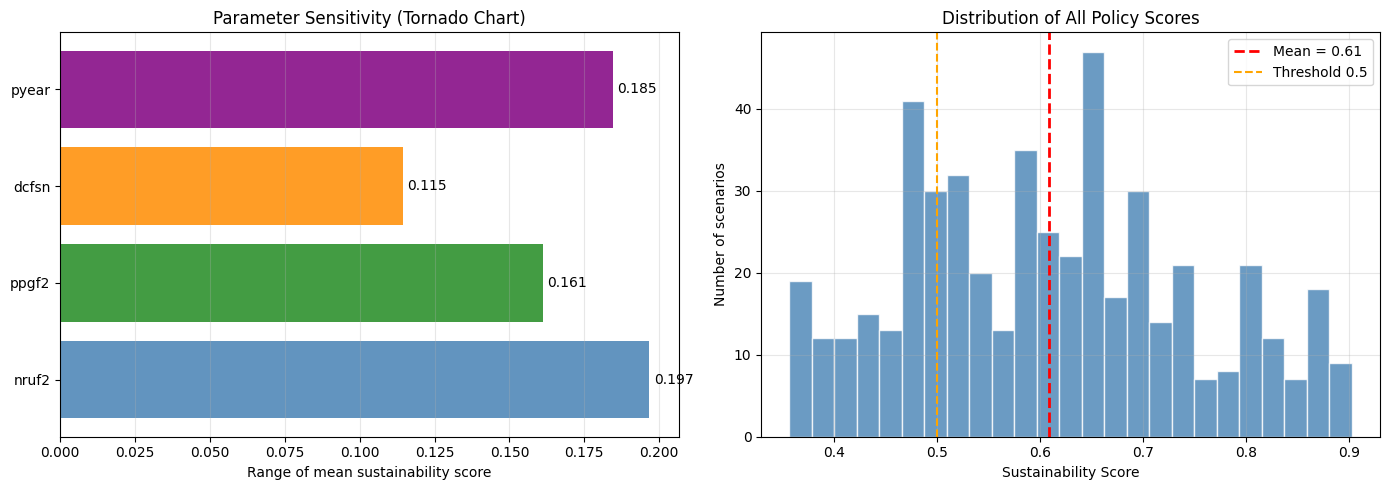

Most influential: nruf2
Scenarios > 0.5: 370/500
Scenarios > 0.7: 124/500


In [10]:
# Sensitivity: which parameter matters most
sensitivity = {p: (lambda g: g.max()-g.min())(df.groupby(p)['total'].mean())
               for p in ['nruf2','ppgf2','dcfsn','pyear']}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(list(sensitivity.keys()), list(sensitivity.values()),
                    color=['steelblue','forestgreen','darkorange','purple'], alpha=0.85)
axes[0].bar_label(bars, fmt='%.3f', padding=3)
axes[0].set_xlabel('Range of mean sustainability score')
axes[0].set_title('Parameter Sensitivity (Tornado Chart)')
axes[0].grid(alpha=0.3, axis='x')

axes[1].hist(df['total'].dropna(), bins=25,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(df['total'].mean(), color='red', ls='--', lw=2,
                label=f'Mean = {df["total"].mean():.2f}')
axes[1].axvline(0.5, color='orange', ls='--', lw=1.5, label='Threshold 0.5')
axes[1].set_xlabel('Sustainability Score')
axes[1].set_ylabel('Number of scenarios')
axes[1].set_title('Distribution of All Policy Scores')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('search_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Most influential: {max(sensitivity, key=sensitivity.get)}')
print(f'Scenarios > 0.5: {(df["total"]>0.5).sum()}/{len(df)}')
print(f'Scenarios > 0.7: {(df["total"]>0.7).sum()}/{len(df)}')

Optimal policy  score=0.903
nruf2=0.1  ppgf2=0.1  dcfsn=2.5  pyear=1975


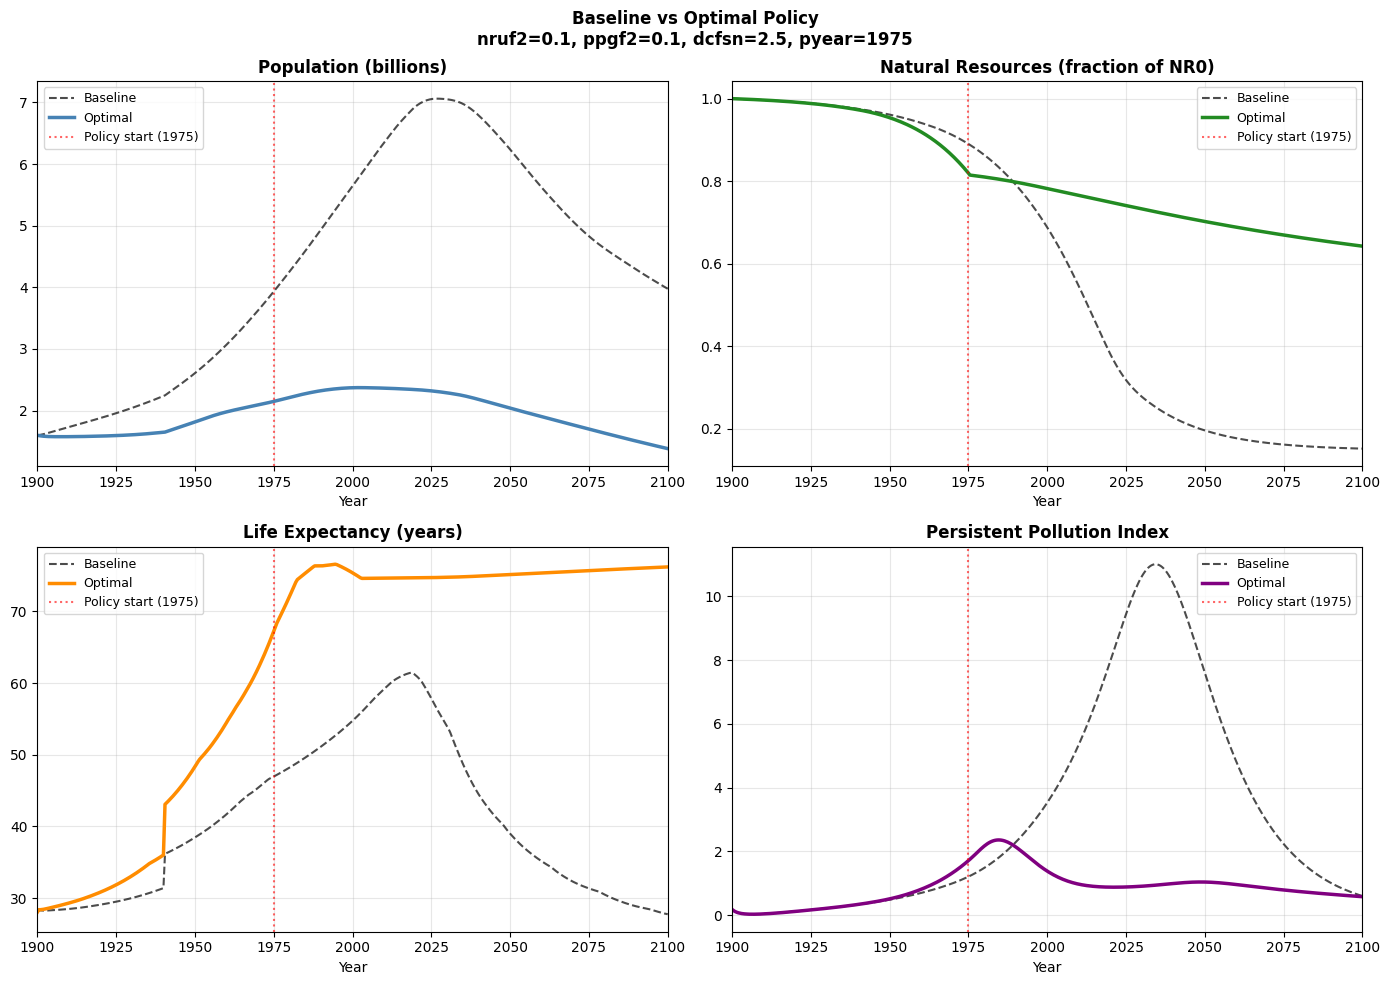

In [11]:
best    = df.iloc[0]
optimal = run_world3(pyear=int(best['pyear']),
                     nruf2=best['nruf2'], ppgf2=best['ppgf2'], dcfsn=best['dcfsn'])

print(f'Optimal policy  score={best["total"]:.3f}')
print(f'nruf2={best["nruf2"]}  ppgf2={best["ppgf2"]}  '
      f'dcfsn={best["dcfsn"]}  pyear={int(best["pyear"])}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Baseline vs Optimal Policy\n'
             f'nruf2={best["nruf2"]}, ppgf2={best["ppgf2"]}, '
             f'dcfsn={best["dcfsn"]}, pyear={int(best["pyear"])}',
             fontsize=12, fontweight='bold')

plots = [
    ('pop',   1e9,            'Population (billions)',               'steelblue'),
    ('nr',    baseline.nr[0], 'Natural Resources (fraction of NR0)', 'forestgreen'),
    ('le',    1,              'Life Expectancy (years)',              'darkorange'),
    ('ppolx', 1,              'Persistent Pollution Index',          'purple'),
]
for ax, (var, scale, title, color) in zip(axes.flat, plots):
    ax.plot(t, getattr(baseline, var)/scale, 'k--', lw=1.5, alpha=0.7, label='Baseline')
    ax.plot(t, getattr(optimal,  var)/scale, color=color, lw=2.5, label='Optimal')
    ax.axvline(best['pyear'], color='red', ls=':', alpha=0.6,
               label=f'Policy start ({int(best["pyear"])})')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Year')
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(1900, 2100)

plt.tight_layout()
plt.savefig('optimal_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

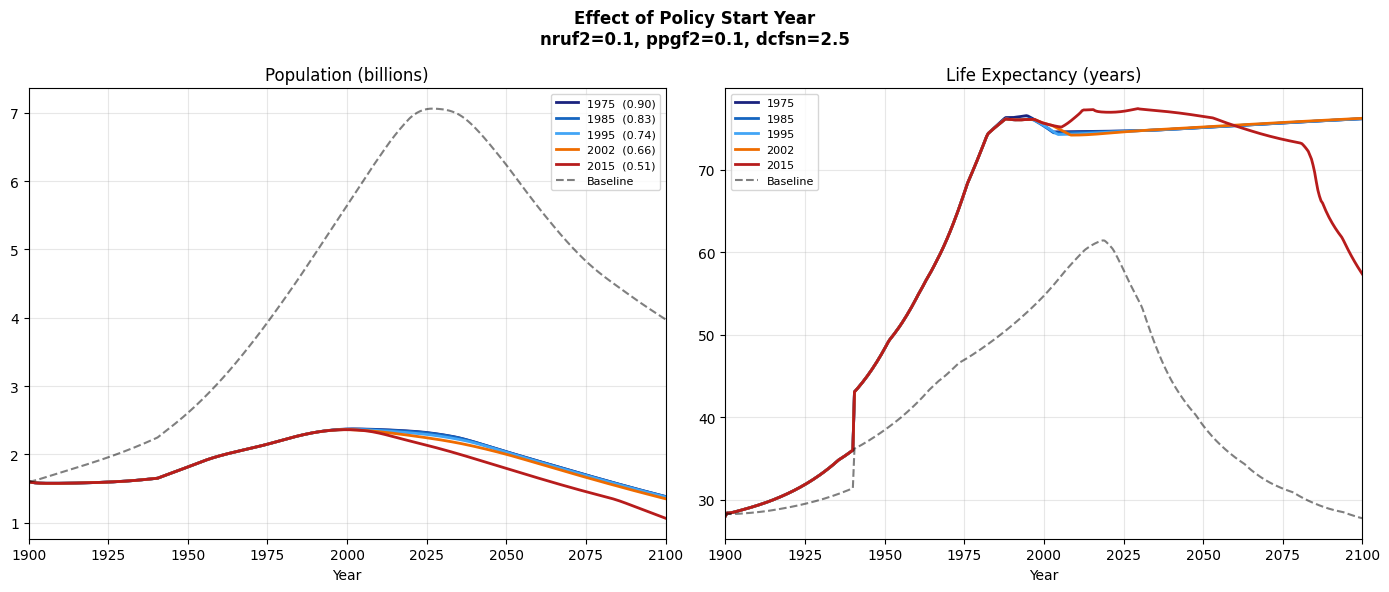

In [12]:
years  = [1975, 1985, 1995, 2002, 2015]
colors = ['#1a237e','#1565c0','#42a5f5','#ef6c00','#b71c1c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Effect of Policy Start Year\n'
             f'nruf2={best["nruf2"]}, ppgf2={best["ppgf2"]}, dcfsn={best["dcfsn"]}',
             fontsize=12, fontweight='bold')

for yr, col in zip(years, colors):
    m = run_world3(pyear=yr, nruf2=best['nruf2'],
                   ppgf2=best['ppgf2'], dcfsn=best['dcfsn'])
    s = sustainability_score(m)
    axes[0].plot(t, m.pop/1e9, color=col, lw=2,
                 label=f'{yr}  ({s["total"]:.2f})')
    axes[1].plot(t, m.le, color=col, lw=2, label=str(yr))

for ax, var, scale, title in [
    (axes[0], 'pop', 1e9, 'Population (billions)'),
    (axes[1], 'le',  1,   'Life Expectancy (years)')]:
    ax.plot(t, getattr(baseline, var)/scale, 'k--', lw=1.5, alpha=0.5, label='Baseline')
    ax.set_title(title); ax.set_xlabel('Year')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlim(1900, 2100)

plt.tight_layout()
plt.savefig('timing_effect.png', dpi=150, bbox_inches='tight')
plt.show()

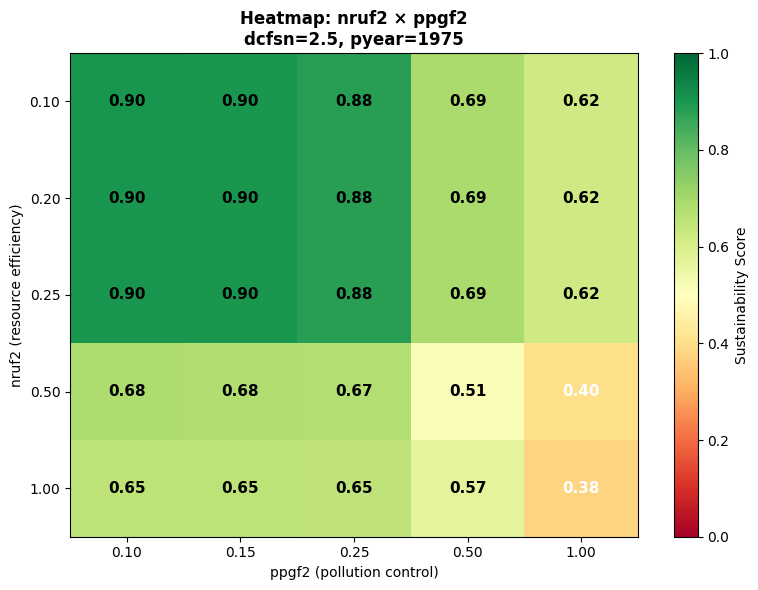

In [13]:
sub   = df[(df['dcfsn'] == best['dcfsn']) & (df['pyear'] == best['pyear'])]
pivot = sub.pivot_table(index='nruf2', columns='ppgf2', values='total', aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{v:.2f}' for v in pivot.index])
ax.set_xlabel('ppgf2 (pollution control)')
ax.set_ylabel('nruf2 (resource efficiency)')
ax.set_title(f'Heatmap: nruf2 × ppgf2\ndcfsn={best["dcfsn"]}, pyear={int(best["pyear"])}',
             fontweight='bold')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=11,
                    fontweight='bold', color='white' if v < 0.45 else 'black')
plt.colorbar(im, ax=ax, label='Sustainability Score')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Summary

In [15]:
op = sustainability_score(optimal)
print('=== REPORT SUMMARY ===')
print(f'{"Metric":<25} {"Baseline":>10} {"Optimal":>10} {"Change":>10}')
print('-' * 57)
rows = [
    ('Total Score',          bs['total'],            op['total'],            ''),
    ('NR Remaining (%)',     bs['nr_remaining_pct'], op['nr_remaining_pct'], '%'),
    ('Max Pollution',        bs['max_pol'],          op['max_pol'],          ''),
    ('Life Exp 2050-2100',   bs['le_late'],          op['le_late'],          'yrs'),
    ('Population 2100 (B)',  bs['pop_2100_B'],       op['pop_2100_B'],       'B'),
]
for name, bv, ov, unit in rows:
    print(f'{name:<25} {bv:>10.2f} {ov:>10.2f} {ov-bv:>+9.2f} {unit}')

print(f'\nTotal scenarios: {len(df)}')
print(f'Score > 0.5:     {(df["total"]>0.5).sum()}')
print(f'Score > 0.7:     {(df["total"]>0.7).sum()}')

=== REPORT SUMMARY ===
Metric                      Baseline    Optimal     Change
---------------------------------------------------------
Total Score                     0.38       0.90     +0.52 
NR Remaining (%)               15.20      64.26    +49.05 %
Max Pollution                  11.00       2.36     -8.64 
Life Exp 2050-2100             31.99      75.67    +43.68 yrs
Population 2100 (B)             4.13       1.44     -2.69 B

Total scenarios: 500
Score > 0.5:     370
Score > 0.7:     124
